<a href="https://colab.research.google.com/github/luccasnn/detector_spam/blob/main/detector_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Dataset real de spam - UCI Machine Learning
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Shape:", df.shape)
print("\nDistribuição:")
print(df['label'].value_counts())
df.head()

Shape: (5572, 2)

Distribuição:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
# Converte label para número
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

# TF-IDF — transforma texto em números
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Vocabulário TF-IDF:", X_train_tfidf.shape[1], "palavras")
print("Treino:", X_train_tfidf.shape[0], "mensagens")
print("Teste:", X_test_tfidf.shape[0], "mensagens")

# Modelo 1 - Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

# Modelo 2 - SVM
svm = LinearSVC(random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("\n=== NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

print("\n=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))

Vocabulário TF-IDF: 5000 palavras
Treino: 4457 mensagens
Teste: 1115 mensagens

=== NAIVE BAYES ===
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115


=== SVM ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



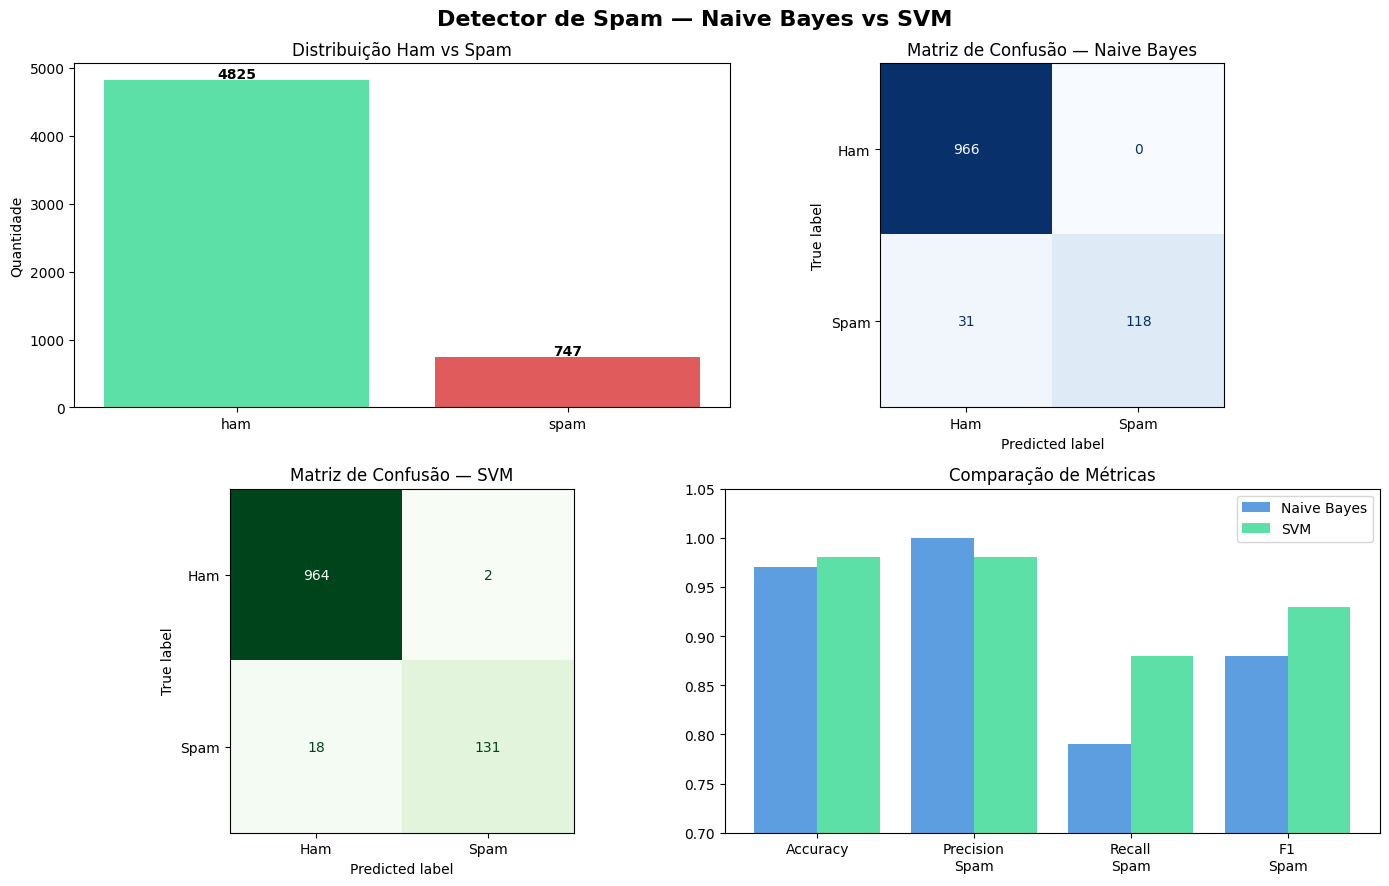

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Detector de Spam — Naive Bayes vs SVM', fontsize=16, fontweight='bold')

# 1. Distribuição ham vs spam
counts = df['label'].value_counts()
axes[0, 0].bar(counts.index, counts.values, color=['#5ce0a8', '#e05c5c'])
axes[0, 0].set_title('Distribuição Ham vs Spam')
axes[0, 0].set_ylabel('Quantidade')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# 2. Matriz de confusão - Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam'])
disp_nb.plot(ax=axes[0, 1], colorbar=False, cmap='Blues')
axes[0, 1].set_title('Matriz de Confusão — Naive Bayes')

# 3. Matriz de confusão - SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=['Ham', 'Spam'])
disp_svm.plot(ax=axes[1, 0], colorbar=False, cmap='Greens')
axes[1, 0].set_title('Matriz de Confusão — SVM')

# 4. Comparação de métricas
metricas = ['Accuracy', 'Precision\nSpam', 'Recall\nSpam', 'F1\nSpam']
nb_vals = [0.97, 1.00, 0.79, 0.88]
svm_vals = [0.98, 0.98, 0.88, 0.93]
x = range(len(metricas))
axes[1, 1].bar([i - 0.2 for i in x], nb_vals, width=0.4, label='Naive Bayes', color='#5c9ee0')
axes[1, 1].bar([i + 0.2 for i in x], svm_vals, width=0.4, label='SVM', color='#5ce0a8')
axes[1, 1].set_xticks(list(x))
axes[1, 1].set_xticklabels(metricas)
axes[1, 1].set_title('Comparação de Métricas')
axes[1, 1].set_ylim(0.7, 1.05)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('detector_spam.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
from google.colab import files

files.download('detector_spam.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>